In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import torch
import matplotlib.pyplot as plt

In [2]:
# import region bounds
from regions import ROSS_BOUNDS

# assign region bounds
x_min = ROSS_BOUNDS["x_min"]
x_max = ROSS_BOUNDS["x_max"]
y_min = ROSS_BOUNDS["y_min"]
y_max = ROSS_BOUNDS["y_max"]

In [3]:
full_tensor = torch.load("data/flux_tensor.pt", weights_only = False)

In [4]:
full_tensor

tensor([[ 0.3674,  0.2412, -0.5594, -2.4007],
        [ 0.4251,  0.2271, -0.5252, -2.4452],
        [ 0.4743,  0.2073, -0.7175, -2.8999],
        ...,
        [ 0.8008,  0.0452,  0.5013, -1.7378],
        [ 0.8008,  0.0452,  0.5012, -1.7369],
        [ 0.8008,  0.0452,  0.5018, -1.7384]])

# Gingham grid

In [5]:
data = full_tensor

def gingham_split_xy(
    data: torch.Tensor,
    # thickness of test stripes within [0, 1] domain
    stripe_width: float = 0.025,
    # distance between test stripes
    stripe_period: float = 0.14,
    # phase offsets
    offset_x: float = 0.0,
    # phase offsets
    offset_y: float = 0.0):
    """
    Split data into train/test by withholding a 'gingham' pattern in x-y:
    test = points lying in vertical OR horizontal stripes.

    data: [N, 4] columns [x_norm, y_norm, vx, vy] with x,y assumed in [0,1].

    Returns:
      train_data, test_data, train_idx, test_idx, test_mask
    """
    # Extract x, y
    x = data[:, 0]
    y = data[:, 1]

    # Vertical stripes: (x - offset_x) mod period < width
    x_phase = torch.remainder(x - offset_x, stripe_period)
    in_vertical = x_phase < stripe_width

    # Horizontal stripes: (y - offset_y) mod period < width
    y_phase = torch.remainder(y - offset_y, stripe_period)
    in_horizontal = y_phase < stripe_width

    # Gingham: union of vertical + horizontal stripes
    test_mask = in_vertical | in_horizontal

    test_idx = torch.nonzero(test_mask, as_tuple = False).squeeze(1)
    train_idx = torch.nonzero(~test_mask, as_tuple = False).squeeze(1)

    test_data = data[test_idx]
    train_data = data[train_idx]

    return train_data, test_data, train_idx, test_idx, test_mask

# Plotting function
def plot_train_test_xy(
    data: torch.Tensor,
    train_idx: torch.Tensor,
    test_idx: torch.Tensor,
    s_train: float = 0.6,
    s_test: float = 0.6, 
    step: int = 150):

    train_idx = train_idx.reshape(-1).to(dtype = torch.long)
    test_idx  = test_idx.reshape(-1).to(dtype = torch.long)

    train_idx_s = train_idx[::step]
    test_idx_s  = test_idx[::step]

    # Gather only sampled points (fast + avoids moving 3.2M points to CPU)
    x_train = data[train_idx_s, 0].detach().cpu()
    y_train = data[train_idx_s, 1].detach().cpu()
    x_test  = data[test_idx_s,  0].detach().cpu()
    y_test  = data[test_idx_s,  1].detach().cpu()

    fig, ax = plt.subplots(figsize=(6.5, 6.0))
    ax.scatter(x_train, y_train, s = s_train, alpha = 0.3, c = "#622736", label = "train")
    ax.scatter(x_test,  y_test,  s = s_test,  alpha = 0.9, c = "#E51405", label = "test")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", "box")
    ax.set_xlabel("x_norm")
    ax.set_ylabel("y_norm")
    ax.legend(frameon = True)
    fig.tight_layout()
    plt.show()

In [6]:
modis_ross = torch.load("data/modis/moa125_2014_hp1_v01_ross_with_grid_no_ocean.pt", weights_only = False)

Total N = 3208089
Train N = 2250146 (70.1%)
Test  N = 957943 (29.9%)


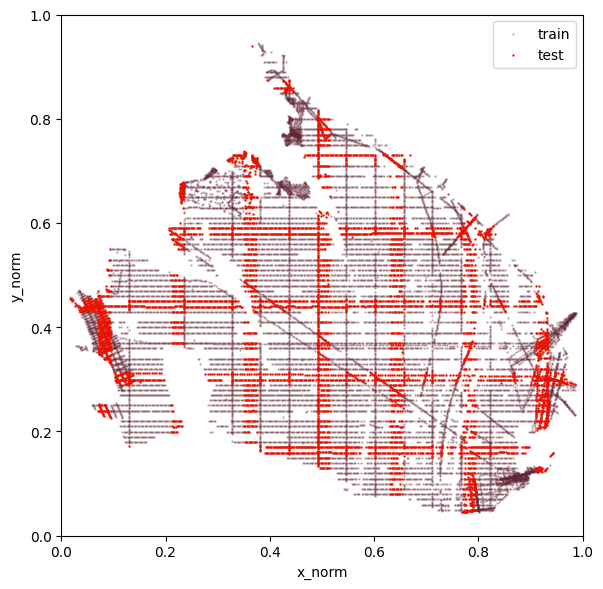

In [7]:
stripe_width = 0.025
stripe_period = 0.14
offset_x = 0.07
offset_y = 0.01

train_data, test_data, train_idx, test_idx, test_mask = gingham_split_xy(
    data,
    stripe_width = stripe_width,
    stripe_period = stripe_period,
    offset_x = offset_x,
    offset_y = offset_y,
)

print(f"Total N = {data.shape[0]}")
print(f"Train N = {train_data.shape[0]} ({train_data.shape[0]/data.shape[0]*100:.1f}%)")
print(f"Test  N = {test_data.shape[0]} ({test_data.shape[0]/data.shape[0]*100:.1f}%)")

plot_train_test_xy(data, train_idx, test_idx)

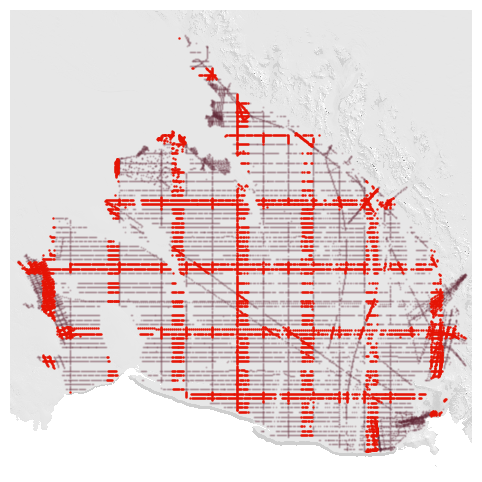

In [10]:
fig, ax = plt.subplots(figsize = (8, 6))

# 1) MODIS as background (draw first)
ax.pcolormesh(
    (modis_ross[0] - x_min)/ (x_max - x_min),
    (modis_ross[1] - y_min) / (y_max - y_min), 
    modis_ross[2],
    cmap = "gray",
    # softer greys
    vmin = -30_000, 
    vmax = 30_000,
    # as less saturated background
    alpha = 0.4, # 0.25 but 0.4 is our standard
    zorder = 0,
)

# 2) SMB on top (draw second)
s_train = 0.6
s_test = 0.6

step = 150

train_idx = train_idx.reshape(-1).to(dtype = torch.long)
test_idx  = test_idx.reshape(-1).to(dtype = torch.long)

train_idx_s = train_idx[::step]
test_idx_s  = test_idx[::step]

# Gather only sampled points (fast + avoids moving 3.2M points to CPU)
x_train = data[train_idx_s, 0].detach().cpu()
y_train = data[train_idx_s, 1].detach().cpu()
x_test  = data[test_idx_s,  0].detach().cpu()
y_test  = data[test_idx_s,  1].detach().cpu()

ax.scatter(x_train, y_train, s = s_train, alpha = 0.15, c = "#622736", label = "train")
ax.scatter(x_test,  y_test,  s = s_test,  alpha = 0.9, c = "#E51405", label = "test")

# ax.legend() # frameon = True

ax.set_aspect("equal")
ax.set_axis_off()

fig.savefig("figures/train_test_ross.png", dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()

In [17]:
(x_max - x_min) * 0.025 / 1000

25.0

# Export 

2.25 M training  
0.95 M test 

In [14]:
print(train_data.shape)
print(test_data.shape)

torch.save(train_data, "data/train_flux_tensor.pt")
torch.save(test_data, "data/test_flux_tensor.pt")

torch.Size([2250146, 4])
torch.Size([957943, 4])
